In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

C:\Users\satya\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [19]:
np.random.seed(42)

data = {
    "Customer_ID": range(1, 501),
    "Age": np.random.randint(21, 65, 500),
    "Annual_Income": np.random.randint(250000, 2500000, 500),
    "Monthly_Spending": np.random.randint(5000, 150000, 500),
    "Credit_Card_Usage": np.random.randint(1000, 200000, 500),
    "Loan_Amount": np.random.randint(0, 3000000, 500),
    "Account_Balance": np.random.randint(10000, 2000000, 500),
    "Digital_Transactions": np.random.randint(1, 150, 500),
   "region" : np.random.choice(
    ["Punjab", "Maharashtra", "Delhi"],
    500
)
    
}

df = pd.DataFrame(data)

df.head()

,Customer_ID,Age,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions,region
0,1,59,253267,75480,25826,392136,496799,21,Maharashtra
1,2,49,2429897,51163,101734,389954,529349,51,Maharashtra
2,3,35,2174596,24816,158702,2135219,765678,38,Punjab
3,4,63,407164,57853,178235,1746621,150905,20,Punjab
4,5,28,785626,101731,99511,18073,280040,132,Maharashtra


In [20]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer_ID           500 non-null    int64
 1   Age                   500 non-null    int32
 2   Annual_Income         500 non-null    int32
 3   Monthly_Spending      500 non-null    int32
 4   Credit_Card_Usage     500 non-null    int32
 5   Loan_Amount           500 non-null    int32
 6   Account_Balance       500 non-null    int32
 7   Digital_Transactions  500 non-null    int32
 8   region                500 non-null    str  
dtypes: int32(7), int64(1), str(1)
memory usage: 25.1 KB


,Customer_ID,Age,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions
count,500.000000,500.000000,5.000000e+02,500.000000,500.000000,5.000000e+02,5.000000e+02,500.000000
mean,250.500000,43.116000,1.363710e+06,78654.274000,101072.446000,1.550187e+06,9.932535e+05,75.130000
std,144.481833,12.733217,6.348165e+05,41082.346577,57153.855808,8.343192e+05,5.649336e+05,43.646387
min,1.000000,21.000000,2.501260e+05,5526.000000,1207.000000,7.967000e+03,1.988500e+04,1.000000
25%,125.750000,32.000000,8.234550e+05,43844.750000,49545.000000,9.022775e+05,4.984992e+05,38.000000
50%,250.500000,44.000000,1.337814e+06,78557.500000,103252.000000,1.549296e+06,1.034063e+06,73.000000
75%,375.250000,53.000000,1.869080e+06,115166.750000,152114.250000,2.251981e+06,1.471012e+06,113.000000
max,500.000000,64.000000,2.495131e+06,149991.000000,199350.000000,2.984852e+06,1.997118e+06,149.000000


In [21]:
features = [
    "Age",
    "Annual_Income",
    "Monthly_Spending",
    "Credit_Card_Usage",
    "Loan_Amount",
    "Account_Balance",
    "Digital_Transactions"
]

X = df[features]

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

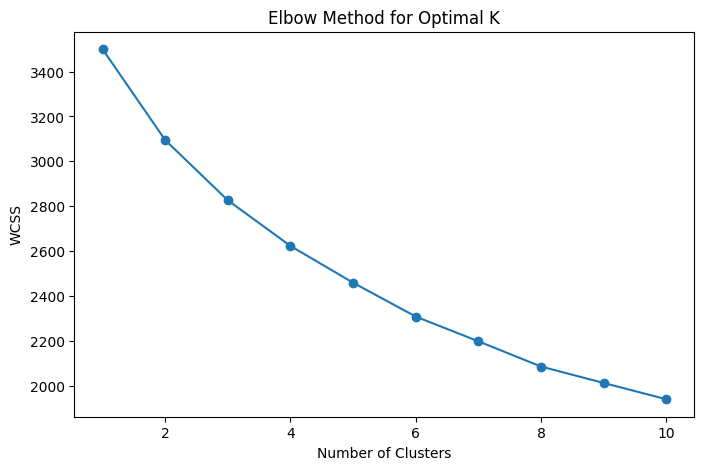

In [23]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [24]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer_ID,Age,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions,region,Cluster
0,1,59,253267,75480,25826,392136,496799,21,Maharashtra,0
1,2,49,2429897,51163,101734,389954,529349,51,Maharashtra,3
2,3,35,2174596,24816,158702,2135219,765678,38,Punjab,3
3,4,63,407164,57853,178235,1746621,150905,20,Punjab,0
4,5,28,785626,101731,99511,18073,280040,132,Maharashtra,3


In [25]:
score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.108


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

df.head()

,Customer_ID,Age,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions,Cluster,PCA1,PCA2
0,1,59,253267,75480,25826,392136,496799,21,0,1.818746,-0.641092
1,2,49,2429897,51163,101734,389954,529349,51,3,-0.378944,-0.830302
2,3,35,2174596,24816,158702,2135219,765678,38,3,-0.515833,0.518909
3,4,63,407164,57853,178235,1746621,150905,20,0,2.213994,1.689230
4,5,28,785626,101731,99511,18073,280040,132,3,-0.676155,-0.978222


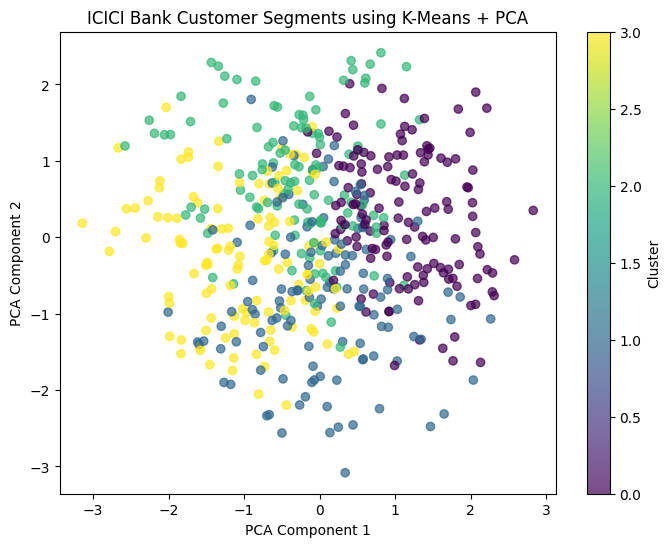

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("ICICI Bank Customer Segments using K-Means + PCA")
plt.colorbar(label="Cluster")
plt.show()

In [11]:
cluster_profile = df.groupby("Cluster")[features].mean().round(2)

cluster_profile

,Age,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions
Cluster,,,,,,,
0,49.56,974759.32,69886.54,94025.43,1982335.12,574558.35,55.89
1,42.15,1865973.40,115551.94,82741.56,1777657.92,970078.25,85.42
2,46.10,897428.81,82829.66,125448.77,1318872.79,1530588.08,80.99
3,33.99,1728724.71,46049.19,104510.93,1051263.36,968414.49,80.37


In [12]:
def segment_name(cluster):
    if cluster == 0:
        return "High Value Customers"
    elif cluster == 1:
        return "Loan Focused Customers"
    elif cluster == 2:
        return "Digital Active Customers"
    else:
        return "Low Engagement Customers"

df["Customer_Segment"] = df["Cluster"].apply(segment_name)

df[["Customer_ID", "Cluster", "Customer_Segment"]].head()

,Customer_ID,Cluster,Customer_Segment
0,1,0,High Value Customers
1,2,3,Low Engagement Customers
2,3,3,Low Engagement Customers
3,4,0,High Value Customers
4,5,3,Low Engagement Customers


In [13]:
segment_summary = df.groupby("Customer_Segment").agg({
    "Customer_ID": "count",
    "Annual_Income": "mean",
    "Monthly_Spending": "mean",
    "Credit_Card_Usage": "mean",
    "Loan_Amount": "mean",
    "Account_Balance": "mean",
    "Digital_Transactions": "mean"
}).round(2)

segment_summary

,Customer_ID,Annual_Income,Monthly_Spending,Credit_Card_Usage,Loan_Amount,Account_Balance,Digital_Transactions
Customer_Segment,,,,,,,
Digital Active Customers,117,897428.81,82829.66,125448.77,1318872.79,1530588.08,80.99
High Value Customers,136,974759.32,69886.54,94025.43,1982335.12,574558.35,55.89
Loan Focused Customers,126,1865973.40,115551.94,82741.56,1777657.92,970078.25,85.42
Low Engagement Customers,121,1728724.71,46049.19,104510.93,1051263.36,968414.49,80.37


In [14]:
df.to_csv("icici_customer_segmentation_output.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [15]:
for segment in df["Customer_Segment"].unique():
    print("\nSegment:", segment)
    print(df[df["Customer_Segment"] == segment][features].mean().round(2))


Segment: High Value Customers
Age                          49.56
Annual_Income            974759.32
Monthly_Spending          69886.54
Credit_Card_Usage         94025.43
Loan_Amount             1982335.12
Account_Balance          574558.35
Digital_Transactions         55.89
dtype: float64

Segment: Low Engagement Customers
Age                          33.99
Annual_Income           1728724.71
Monthly_Spending          46049.19
Credit_Card_Usage        104510.93
Loan_Amount             1051263.36
Account_Balance          968414.49
Digital_Transactions         80.37
dtype: float64

Segment: Digital Active Customers
Age                          46.10
Annual_Income            897428.81
Monthly_Spending          82829.66
Credit_Card_Usage        125448.77
Loan_Amount             1318872.79
Account_Balance         1530588.08
Digital_Transactions         80.99
dtype: float64

Segment: Loan Focused Customers
Age                          42.15
Annual_Income           1865973.40
Monthly_Spending